<a href="https://colab.research.google.com/github/KANNIKADEVI475/smartCCTV/blob/main/smartCCTV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install kagglehub


In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("snehilsanyal/weapon-detection-test")

print("Path to dataset files:", path)

100%|██████████| 194M/194M [00:10<00:00, 19.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/snehilsanyal/weapon-detection-test/versions/5


In [6]:
import os

print(os.listdir(path))

['metadata.csv', 'test', 'weapon_detection']


In [7]:
import os

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".yaml") or file.endswith(".yml"):
            print(os.path.join(root, file))

In [8]:
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = '    ' * level
    print(indent + os.path.basename(root) + '/')

    for file in files[:10]:
        print(indent + '    ' + file)

5/
    metadata.csv
    test/
        test/
            terrorists2.jpg
            terrorists.jpg
            giphy.gif
            weaponsgta5.gif
            weapons.jpg
            mafia-mafia-game.gif
            army.jpg
            weapons2.jpg
    weapon_detection/
        val/
            labels/
                SMG_11.txt
                Bazooka_70.txt
                Sniper_72.txt
                Grenade Launcher_78.txt
                Knife_93.txt
                SMG_19.txt
                Sniper_50.txt
                Bazooka_37.txt
                Grenade Launcher_22.txt
                Knife_75.txt
            images/
                Sword_67.jpeg
                Shotgun_44.jpeg
                Sword_96.jpeg
                Sniper_36.jpeg
                Sword_21.png
                SMG_22.jpeg
                Shotgun_93.jpeg
                Knife_11.jpeg
                Handgun_99.jpeg
                Handgun_27.jpeg
        train/
            labels/
                SM

In [9]:
import pandas as pd
import os

metadata_path = os.path.join(path, "metadata.csv")

df = pd.read_csv(metadata_path)

print(df)

                    imagefile                labelfile  target  train_id
0     Automatic Rifle_10.jpeg   Automatic Rifle_10.txt       0         1
1    Automatic Rifle_100.jpeg  Automatic Rifle_100.txt       0         1
2     Automatic Rifle_11.jpeg   Automatic Rifle_11.txt       0         1
3     Automatic Rifle_12.jpeg   Automatic Rifle_12.txt       0         1
4     Automatic Rifle_13.jpeg   Automatic Rifle_13.txt       0         0
..                        ...                      ...     ...       ...
709             Sword_95.jpeg             Sword_95.txt       8         1
710             Sword_96.jpeg             Sword_96.txt       8         0
711             Sword_97.jpeg             Sword_97.txt       8         1
712             Sword_98.jpeg             Sword_98.txt       8         1
713             Sword_99.jpeg             Sword_99.txt       8         0

[714 rows x 4 columns]


In [10]:
print(df[["imagefile", "target"]].drop_duplicates().sort_values("target").to_string(index=False))

               imagefile  target
 Automatic Rifle_10.jpeg       0
Automatic Rifle_100.jpeg       0
 Automatic Rifle_11.jpeg       0
 Automatic Rifle_12.jpeg       0
 Automatic Rifle_13.jpeg       0
 Automatic Rifle_14.jpeg       0
  Automatic Rifle_15.png       0
  Automatic Rifle_16.png       0
 Automatic Rifle_17.jpeg       0
  Automatic Rifle_18.png       0
 Automatic Rifle_51.jpeg       0
 Automatic Rifle_52.jpeg       0
 Automatic Rifle_53.jpeg       0
 Automatic Rifle_54.jpeg       0
 Automatic Rifle_55.jpeg       0
 Automatic Rifle_56.jpeg       0
 Automatic Rifle_57.jpeg       0
  Automatic Rifle_6.jpeg       0
 Automatic Rifle_61.jpeg       0
 Automatic Rifle_68.jpeg       0
 Automatic Rifle_69.jpeg       0
  Automatic Rifle_7.jpeg       0
 Automatic Rifle_24.jpeg       0
 Automatic Rifle_23.jpeg       0
 Automatic Rifle_22.jpeg       0
 Automatic Rifle_39.jpeg       0
 Automatic Rifle_37.jpeg       0
 Automatic Rifle_38.jpeg       0
 Automatic Rifle_34.jpeg       0
 Automatic

In [11]:
print(path)

/root/.cache/kagglehub/datasets/snehilsanyal/weapon-detection-test/versions/5


In [12]:
yaml_content="""
path: /root/.cache/kagglehub/datasets/snehilsanyal/weapon-detection-test/versions/5

train: train/images
val: val/images

names:
  0: Automatic Rifle
  1: Bazooka
  2: Grenade Launcher
  3: Handgun
  4: Knife
  5: Shotgun
  6: SMG
  7: Sniper
  8: Sword

"""


In [13]:
with open("/content/data.yaml","w") as f:
  f.write(yaml_content)

In [14]:
with open("/content/data.yaml", "r") as f:
    print(f.read())


path: /root/.cache/kagglehub/datasets/snehilsanyal/weapon-detection-test/versions/5

train: train/images
val: val/images

names:
  0: Automatic Rifle
  1: Bazooka
  2: Grenade Launcher
  3: Handgun
  4: Knife
  5: Shotgun
  6: SMG
  7: Sniper
  8: Sword
  



In [15]:
import os

print(os.path.exists("/content/data.yaml"))

True


In [16]:
dataset_path = "/root/.cache/kagglehub/datasets/snehilsanyal/weapon-detection-test/versions/5"

In [17]:
weapon_path = os.path.join(dataset_path, "weapon_detection")

In [18]:
import os

label_dir = os.path.join(weapon_path, "train", "labels")

sample_label = os.listdir(label_dir)[0]

print("Label file:", sample_label)

with open(os.path.join(label_dir, sample_label), "r") as f:
    print(f.read())

Label file: SMG_26.txt
0 0.504167 0.500000 0.815000 0.692308



In [19]:
class_ids = set()

for file in os.listdir(label_dir):
    if file.endswith(".txt"):
        with open(os.path.join(label_dir, file), "r") as f:
            for line in f:
                values = line.strip().split()
                if values:
                    class_ids.add(int(values[0]))

print("Class IDs found:", sorted(class_ids))

Class IDs found: [0, 1, 2, 4, 5]


In [20]:
import os

label_dir = os.path.join(weapon_path, "train", "labels")

wrong_labels = []

for file in os.listdir(label_dir):
    if not file.endswith(".txt"):
        continue

    # Get expected class from filename
    filename = file.lower()

    if filename.startswith("automatic rifle"):
        expected = 0
    elif filename.startswith("bazooka"):
        expected = 1
    elif filename.startswith("grenade launcher"):
        expected = 2
    elif filename.startswith("handgun"):
        expected = 3
    elif filename.startswith("knife"):
        expected = 4
    elif filename.startswith("shotgun"):
        expected = 5
    elif filename.startswith("smg"):
        expected = 6
    elif filename.startswith("sniper"):
        expected = 7
    elif filename.startswith("sword"):
        expected = 8
    else:
        continue

    with open(os.path.join(label_dir, file), "r") as f:
        for line in f:
            values = line.strip().split()

            if not values:
                continue

            actual = int(values[0])

            if actual != expected:
                wrong_labels.append(
                    (file, expected, actual)
                )

print("Wrong labels:", len(wrong_labels))

for item in wrong_labels[:30]:
    print(item)

Wrong labels: 813
('SMG_26.txt', 6, 0)
('Handgun_88.txt', 3, 0)
('Shotgun_37.txt', 5, 0)
('Shotgun_37.txt', 5, 0)
('Shotgun_65.txt', 5, 0)
('Shotgun_92.txt', 5, 0)
('Automatic Rifle_44.txt', 0, 2)
('Grenade Launcher_95.txt', 2, 0)
('Handgun_25.txt', 3, 0)
('Handgun_25.txt', 3, 0)
('Grenade Launcher_7.txt', 2, 0)
('Sword_69.txt', 8, 5)
('Knife_72.txt', 4, 0)
('Shotgun_39.txt', 5, 0)
('Grenade Launcher_12.txt', 2, 0)
('Grenade Launcher_52.txt', 2, 0)
('SMG_37.txt', 6, 0)
('Shotgun_84.txt', 5, 0)
('Knife_7.txt', 4, 0)
('Handgun_77.txt', 3, 0)
('Grenade Launcher_66.txt', 2, 0)
('Shotgun_18.txt', 5, 0)
('Shotgun_52.txt', 5, 0)
('Shotgun_85.txt', 5, 0)
('Sniper_45.txt', 7, 2)
('Sniper_45.txt', 7, 2)
('Knife_78.txt', 4, 0)
('Shotgun_60.txt', 5, 0)
('Handgun_46.txt', 3, 0)
('Handgun_46.txt', 3, 0)


In [21]:
class_map = {
    "automatic rifle": 0,
    "bazooka": 1,
    "grenade launcher": 2,
    "handgun": 3,
    "knife": 4,
    "shotgun": 5,
    "smg": 6,
    "sniper": 7,
    "sword": 8
}

from collections import Counter

corrections = Counter()

for file in os.listdir(label_dir):
    if not file.endswith(".txt"):
        continue

    filename = file.lower()

    expected_class = None

    for weapon, class_id in class_map.items():
        if filename.startswith(weapon):
            expected_class = class_id
            break

    if expected_class is None:
        continue

    with open(os.path.join(label_dir, file), "r") as f:
        for line in f:
            values = line.strip().split()

            if values:
                actual_class = int(values[0])

                if actual_class != expected_class:
                    corrections[(actual_class, expected_class)] += 1

print("Corrections that would be made:")
for (old, new), count in sorted(corrections.items()):
    print(f"{old} → {new}: {count}")

Corrections that would be made:
0 → 1: 63
0 → 2: 78
0 → 3: 121
0 → 4: 139
0 → 5: 91
0 → 6: 114
1 → 0: 3
1 → 2: 1
1 → 5: 5
1 → 6: 1
2 → 0: 2
2 → 6: 2
2 → 7: 83
4 → 7: 2
5 → 8: 108


In [22]:
import os
import shutil

label_dir = os.path.join(weapon_path, "train", "labels")
backup_dir = os.path.join(weapon_path, "train", "labels_backup")

if not os.path.exists(backup_dir):
    shutil.copytree(label_dir, backup_dir)
    print("Backup created:", backup_dir)
else:
    print("Backup already exists.")

Backup created: /root/.cache/kagglehub/datasets/snehilsanyal/weapon-detection-test/versions/5/weapon_detection/train/labels_backup


In [23]:
val_label_dir = os.path.join(weapon_path, "val", "labels")
val_backup_dir = os.path.join(weapon_path, "val", "labels_backup")

if not os.path.exists(val_backup_dir):
    shutil.copytree(val_label_dir, val_backup_dir)
    print("Validation backup created:", val_backup_dir)
else:
    print("Validation backup already exists.")

Validation backup created: /root/.cache/kagglehub/datasets/snehilsanyal/weapon-detection-test/versions/5/weapon_detection/val/labels_backup


In [24]:
class_map = {
    "automatic rifle": 0,
    "bazooka": 1,
    "grenade launcher": 2,
    "handgun": 3,
    "knife": 4,
    "shotgun": 5,
    "smg": 6,
    "sniper": 7,
    "sword": 8
}

In [25]:
import os

def fix_labels(label_dir, class_map):
    changed_lines = 0
    changed_files = 0

    for file in os.listdir(label_dir):

        if not file.endswith(".txt"):
            continue

        filename = file.lower()

        expected_class = None

        for weapon, class_id in class_map.items():
            if filename.startswith(weapon):
                expected_class = class_id
                break

        if expected_class is None:
            continue

        file_path = os.path.join(label_dir, file)

        with open(file_path, "r") as f:
            lines = f.readlines()

        new_lines = []
        file_changed = False

        for line in lines:

            values = line.strip().split()

            if len(values) != 5:
                new_lines.append(line)
                continue

            old_class = int(values[0])

            if old_class != expected_class:
                values[0] = str(expected_class)
                changed_lines += 1
                file_changed = True

            new_lines.append(" ".join(values) + "\n")

        if file_changed:
            changed_files += 1

        with open(file_path, "w") as f:
            f.writelines(new_lines)

    return changed_files, changed_lines

In [26]:
train_label_dir = os.path.join(
    weapon_path,
    "train",
    "labels"
)

train_files, train_lines = fix_labels(
    train_label_dir,
    class_map
)

print("Train files corrected:", train_files)
print("Train annotation lines corrected:", train_lines)

Train files corrected: 515
Train annotation lines corrected: 813


In [27]:
val_label_dir = os.path.join(
    weapon_path,
    "val",
    "labels"
)

val_files, val_lines = fix_labels(
    val_label_dir,
    class_map
)

print("Validation files corrected:", val_files)
print("Validation annotation lines corrected:", val_lines)

Validation files corrected: 128
Validation annotation lines corrected: 196


In [28]:
def get_class_ids(label_dir):

    class_ids = set()

    for file in os.listdir(label_dir):

        if not file.endswith(".txt"):
            continue

        with open(os.path.join(label_dir, file), "r") as f:

            for line in f:

                values = line.strip().split()

                if values:
                    class_ids.add(int(values[0]))

    return sorted(class_ids)

In [29]:
train_classes = get_class_ids(train_label_dir)
val_classes = get_class_ids(val_label_dir)

print("Train class IDs:", train_classes)
print("Val class IDs:", val_classes)

Train class IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Val class IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8]


In [30]:
wrong_labels = []

for file in os.listdir(train_label_dir):

    if not file.endswith(".txt"):
        continue

    filename = file.lower()

    expected_class = None

    for weapon, class_id in class_map.items():
        if filename.startswith(weapon):
            expected_class = class_id
            break

    if expected_class is None:
        continue

    with open(os.path.join(train_label_dir, file), "r") as f:

        for line in f:

            values = line.strip().split()

            if not values:
                continue

            actual_class = int(values[0])

            if actual_class != expected_class:
                wrong_labels.append(
                    (file, expected_class, actual_class)
                )

print("Remaining wrong labels:", len(wrong_labels))

Remaining wrong labels: 0


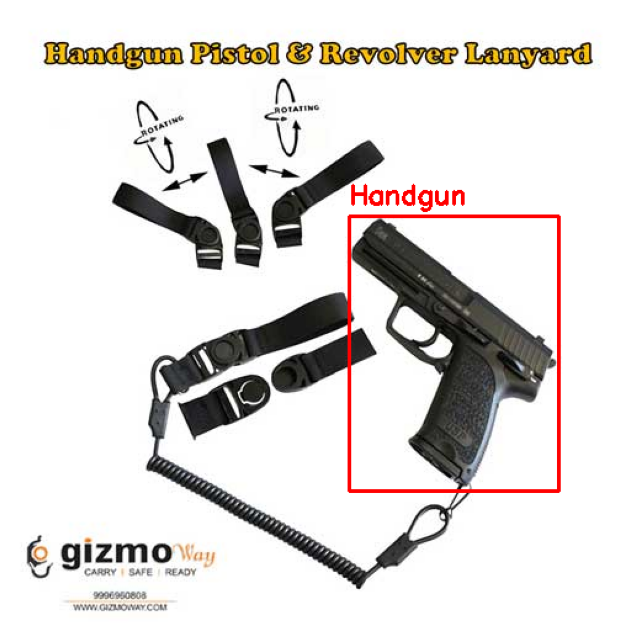

In [31]:
import cv2
import os
import matplotlib.pyplot as plt

image_dir = os.path.join(weapon_path, "train", "images")
label_dir = os.path.join(weapon_path, "train", "labels")

class_names = [
    "Automatic Rifle",
    "Bazooka",
    "Grenade Launcher",
    "Handgun",
    "Knife",
    "Shotgun",
    "SMG",
    "Sniper",
    "Sword"
]

# Pick one image
image_name = "Handgun_38.jpeg"

image_path = os.path.join(image_dir, image_name)
label_path = os.path.join(
    label_dir,
    os.path.splitext(image_name)[0] + ".txt"
)

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

height, width = image.shape[:2]

with open(label_path, "r") as f:
    for line in f:
        values = line.strip().split()

        class_id = int(values[0])
        x_center = float(values[1])
        y_center = float(values[2])
        box_width = float(values[3])
        box_height = float(values[4])

        # YOLO normalized coordinates → pixel coordinates
        x1 = int((x_center - box_width / 2) * width)
        y1 = int((y_center - box_height / 2) * height)
        x2 = int((x_center + box_width / 2) * width)
        y2 = int((y_center + box_height / 2) * height)

        cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)

        cv2.putText(
            image,
            class_names[class_id],
            (x1, max(y1 - 10, 0)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 0, 0),
            2
        )

plt.figure(figsize=(10, 8))
plt.imshow(image)
plt.axis("off")
plt.show()

In [32]:
!pip install -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 7.8 MB/s eta 0:00:00


In [33]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [38]:
import os

print(os.path.exists("/content/data.yaml"))

True


In [35]:
print(open("/content/data.yaml").read())


path: /root/.cache/kagglehub/datasets/snehilsanyal/weapon-detection-test/versions/5

train: train/images
val: val/images

names:
  0: Automatic Rifle
  1: Bazooka
  2: Grenade Launcher
  3: Handgun
  4: Knife
  5: Shotgun
  6: SMG
  7: Sniper
  8: Sword
  



In [36]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [42]:
yaml_content = """
path: /root/.cache/kagglehub/datasets/snehilsanyal/weapon-detection-test/versions/5/weapon_detection

train: train/images
val: val/images

names:
  0: Automatic Rifle
  1: Bazooka
  2: Grenade Launcher
  3: Handgun
  4: Knife
  5: Shotgun
  6: SMG
  7: Sniper
  8: Sword
"""

with open("/content/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml recreated successfully!")

data.yaml recreated successfully!


In [45]:
results = model.train(
    data="/content/data.yaml",
    epochs=50,
    imgsz=640,
    batch=4
)

Ultralytics 8.4.133 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-4, nbs=64, nms=False, opset=None, optim

In [46]:
from google.colab import files

files.download("/content/runs/detect/train-4/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>